# Analyse des causes de démission chez TechNova Partners

## Etape 1 - Effectuez une analyse exploratoire des fichiers de données

### Objectif

Un DataFrame central, issu d’une jointure entre les fichiers de départ.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [72]:
# on import les dataset depuis le dossier dataset
df1 = pd.read_csv('dataset/extrait_sirh.csv')
df2 = pd.read_csv('dataset/extrait_eval.csv')
df3 = pd.read_csv('dataset/extrait_sondage.csv')

In [73]:
# entete de chaque dataset
df1.head()
df1.shape

(1470, 12)

In [74]:
# on vas mettre l'index en colonne
#df2 = df2.reset_index()
# eval_number etant un object on le converti en int avec la méthode str.extract comme un regex
# \d chiffre de 0-9 => + un ou plusieurs => () ce qu'on veut extraire
df2["id_employee"] = df2["eval_number"].str.extract(r'(\d+)').astype(int)
# je supprime l'ancien eval
df2 = df2.drop(columns='eval_number')
df2.head()
df2.shape

(1470, 10)

In [75]:
df3.head()
df3.shape

(1470, 12)

In [76]:
# on calcul le taux de correspondances si un taux de 1.0% les deux clé commun sont identique df1 et df2
len(set(df1["id_employee"]) & set(df2["id_employee"])) / len(set(df1["id_employee"]))

1.0

In [77]:
# on identifie les clés communes { ici : id_employee = eval_number = code_sondage  }
# on applique avec pandas un merge 
df_central = pd.merge(df1, df2, on="id_employee", how="left")
df_central.shape

(1470, 21)

In [78]:
#idem pour df_central & df3 on calcul le taux de correspondance
len(set(df_central["id_employee"]) & set(df3["code_sondage"])) / len(set(df_central["id_employee"]))

1.0

In [79]:
# on merge de nouveau df3 dans central
df_central = pd.merge(df_central, df3, left_on="id_employee", right_on="code_sondage" ,how="left")

In [80]:
df_central.shape

(1470, 33)

In [81]:
df_central.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,...,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,...,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,...,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,...,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,...,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,...,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [82]:
df_central.columns

Index(['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital',
       'departement', 'poste', 'nombre_experiences_precedentes',
       'nombre_heures_travailless', 'annee_experience_totale',
       'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'nombre_employee_sous_responsabilite',
       'code_sondage', 'distance_domicile_travail', 'niveau_education',
       'domaine_etude', 'ayant_enfants', 'frequence_deplacement',
       'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel'],
      dtype='object')

In [83]:
# methode pour voir les clés commun avec describe()
# ici je prends id_employer clé principal je regarde les statistiques descriptives
# dans chaque df2 & 3 je vais la descriptives identiques 
df1['id_employee'].describe()

count    1470.000000
mean     1024.865306
std       602.024335
min         1.000000
25%       491.250000
50%      1020.500000
75%      1555.750000
max      2068.000000
Name: id_employee, dtype: float64

In [84]:
# ici n'ayant pas de stats qui corresponds j'analyse manuellement les datas. je remarque que eval_number pourrais correspondre
# mais etant un object je le convertir en int64() => voir méthode au dessus avec .str.extract() avec nouveau nom eval_number_int
# et bingo les stats descriptives sont identiques
df2.describe()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,id_employee
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741,1024.865306
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824,602.024335
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000,491.250000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,1020.500000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,1555.750000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,2068.000000


In [85]:
# ici on peut voir que la colonnes code_sondage est identique a id_employé = donc clé commun
df3.describe()

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129
std,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136
min,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000
50%,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000
75%,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000
max,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000


<Axes: xlabel='satisfaction_employee_environnement', ylabel='Density'>

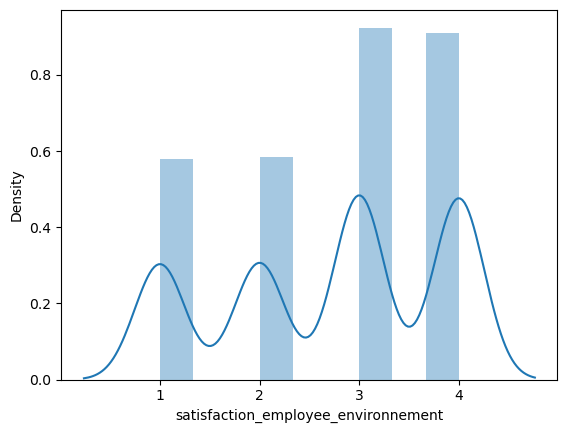

In [86]:
# les trois clés détecté et lié dans un dataframe central on creer les graphiques
sns.distplot(df_central['satisfaction_employee_environnement'])

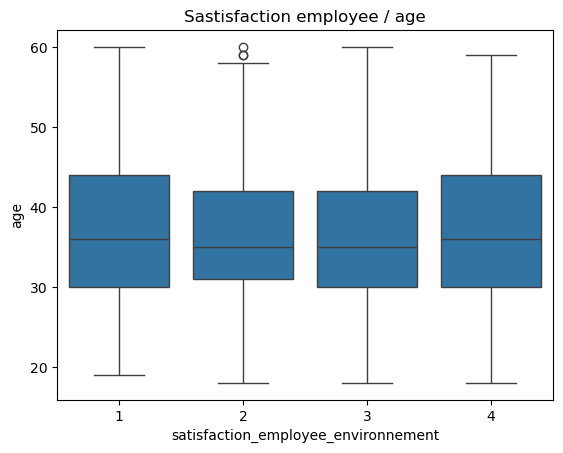

In [87]:
# on vas voir sastifaction employee dans leur environemment
sns.boxplot(data=df_central, y='age', x='satisfaction_employee_environnement')
plt.title('Sastisfaction employee / age')
plt.show()

<Axes: xlabel='a_quitte_l_entreprise', ylabel='satisfaction_employee_environnement'>

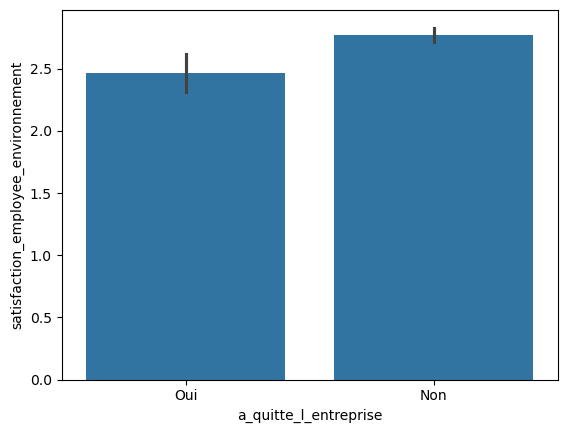

In [88]:
# satisfaction employee environnement
sns.barplot(data=df_central, x="a_quitte_l_entreprise", y="satisfaction_employee_environnement")

<Axes: xlabel='age'>

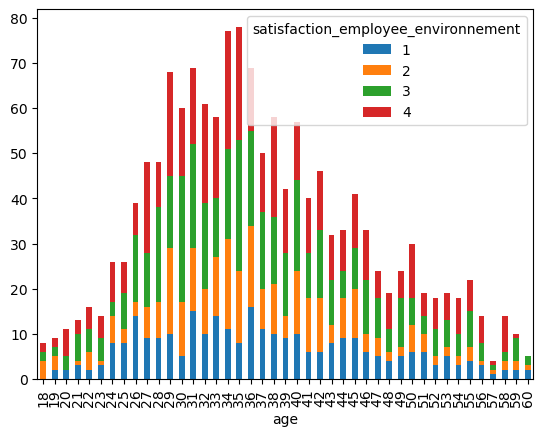

In [89]:
pd.crosstab(df_central['age'], df_central['satisfaction_employee_environnement']).plot(kind='bar', stacked=True)

## Etape 2 - Préparez la donnée pour la modélisation

### Objectif

Préparez la donnée pour la modélisation

In [90]:
# on verifie le dataset avant de faire un corrélation et scaler 
df_central.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   id_employee                                1470 non-null   int64 
 1   age                                        1470 non-null   int64 
 2   genre                                      1470 non-null   object
 3   revenu_mensuel                             1470 non-null   int64 
 4   statut_marital                             1470 non-null   object
 5   departement                                1470 non-null   object
 6   poste                                      1470 non-null   object
 7   nombre_experiences_precedentes             1470 non-null   int64 
 8   nombre_heures_travailless                  1470 non-null   int64 
 9   annee_experience_totale                    1470 non-null   int64 
 10  annees_dans_l_entreprise            

In [91]:
# on transform les object en numérique avec getdummies () idem à OneHotEncoder 
#df = pd.get_dummies(df_central, columns=['genre', ], drop_first=True)
print()
for col, value in df_central.dtypes.items():
    if value == 'object':
        #print(col ,'-', value)
        df_central = pd.get_dummies(df_central, columns=[col], drop_first=True)
        
# on controle de nouveau 
df_central.info() # avec info() on apercois que dtype est converti en bool or pour afficher le grap avec sns.heatmap on aura une erreur



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 59 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   revenu_mensuel                             1470 non-null   int64
 3   nombre_experiences_precedentes             1470 non-null   int64
 4   nombre_heures_travailless                  1470 non-null   int64
 5   annee_experience_totale                    1470 non-null   int64
 6   annees_dans_l_entreprise                   1470 non-null   int64
 7   annees_dans_le_poste_actuel                1470 non-null   int64
 8   satisfaction_employee_environnement        1470 non-null   int64
 9   note_evaluation_precedente                 1470 non-null   int64
 10  niveau_hierarchique_poste                  1470

In [92]:
# on converti les bool en int
# on utilise une boucle 
df_central = df_central.astype({col:int for col, value in df_central.dtypes.items() if value == 'bool'  })

In [93]:
# on fais un nettoyage des données NaN
df_central = df_central.dropna()

In [94]:
# on corr()
df_corr = df_central.copy()
df_corr.corr()


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,...,augementation_salaire_precedente_24 %,augementation_salaire_precedente_25 %,a_quitte_l_entreprise_Oui,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel
id_employee,1.000000,-0.010145,-0.014829,-0.001251,NaN,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,...,-0.002897,0.033069,-0.010577,0.005938,-0.000609,-0.014487,0.035345,-0.008689,-0.007980,-0.007976
age,-0.010145,1.000000,0.497855,0.299635,NaN,0.680381,0.311309,0.212901,0.010146,0.029820,...,0.008537,-0.003812,-0.159205,-0.027604,0.016824,0.038162,0.001696,-0.006354,-0.024743,0.028791
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,NaN,0.772893,0.514285,0.363818,-0.006259,-0.015271,...,0.008805,0.018788,-0.159840,-0.049695,-0.007054,0.062576,0.021456,0.001025,-0.031658,0.038779
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,NaN,0.237639,-0.118421,-0.090754,0.012594,0.015012,...,-0.010462,-0.063109,0.043494,-0.013819,-0.006131,-0.018611,0.031007,0.024826,-0.039718,0.032401
nombre_heures_travailless,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee_experience_totale,-0.014365,0.680381,0.772893,0.237639,NaN,1.000000,0.628133,0.460365,-0.002693,-0.005533,...,-0.006538,0.034170,-0.171063,-0.041577,-0.003630,0.025779,0.005505,0.024890,-0.012177,0.030320
annees_dans_l_entreprise,-0.011240,0.311309,0.514285,-0.118421,NaN,0.628133,1.000000,0.758754,0.001458,-0.021355,...,0.003584,0.058431,-0.134392,-0.021399,-0.002019,0.031365,-0.005146,0.010805,0.012991,-0.016274
annees_dans_le_poste_actuel,-0.008416,0.212901,0.363818,-0.090754,NaN,0.460365,0.758754,1.000000,0.018007,0.008717,...,0.003459,0.059558,-0.160545,0.009683,0.018343,0.025126,-0.025443,-0.026418,0.001680,-0.009147
satisfaction_employee_environnement,0.017621,0.010146,-0.006259,0.012594,NaN,-0.002693,0.001458,0.018007,1.000000,-0.008278,...,-0.006071,-0.016936,-0.103369,0.027713,-0.024526,0.000479,-0.006898,-0.021299,-0.012624,0.008496
note_evaluation_precedente,-0.006888,0.029820,-0.015271,0.015012,NaN,-0.005533,-0.021355,0.008717,-0.008278,1.000000,...,-0.002648,0.007489,-0.130016,-0.004519,0.003228,-0.018657,0.002079,0.017103,0.004424,0.026714


In [95]:
# on controle le nombre de µNaN
df_corr.isna().sum()

id_employee                                  0
age                                          0
revenu_mensuel                               0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
note_evaluation_actuelle                     0
nombre_participation_pee                     0
nb_formations_suivies                        0
nombre_employee_sous_responsabilite          0
code_sondage                                 0
distance_domicile_travail                    0
niveau_education                             0
annees_depuis

In [96]:
# on vois deux colonnes avec des data NaN on vas directement supprimer ces colonnes 
df_corr = df_corr.drop(columns=['nombre_employee_sous_responsabilite', 'nombre_heures_travailless'], axis=1)

In [97]:
# on controle de nouveau avec corr()
#df_corr.corr(numeric_only=True)
#df_corr.corr()

In [98]:
df_corr.info()
#df_facto.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   id_employee                                1470 non-null   int64
 1   age                                        1470 non-null   int64
 2   revenu_mensuel                             1470 non-null   int64
 3   nombre_experiences_precedentes             1470 non-null   int64
 4   annee_experience_totale                    1470 non-null   int64
 5   annees_dans_l_entreprise                   1470 non-null   int64
 6   annees_dans_le_poste_actuel                1470 non-null   int64
 7   satisfaction_employee_environnement        1470 non-null   int64
 8   note_evaluation_precedente                 1470 non-null   int64
 9   niveau_hierarchique_poste                  1470 non-null   int64
 10  satisfaction_employee_nature_travail       1470 

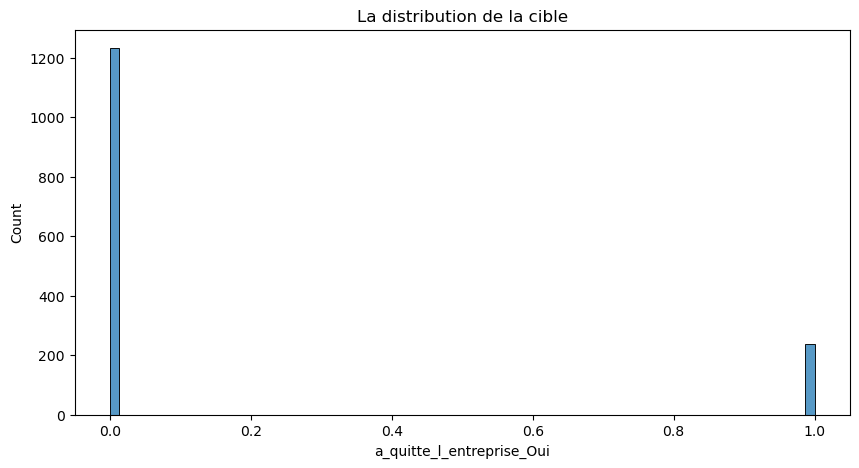

In [99]:
# on recupere la cible ici a_quitte_l_entreprise_Oui
plt.figure(figsize=(10,5))
sns.histplot(df_corr['a_quitte_l_entreprise_Oui'])
plt.title('La distribution de la cible')
plt.show()

In [100]:
#sns.pairplot(df_corr)

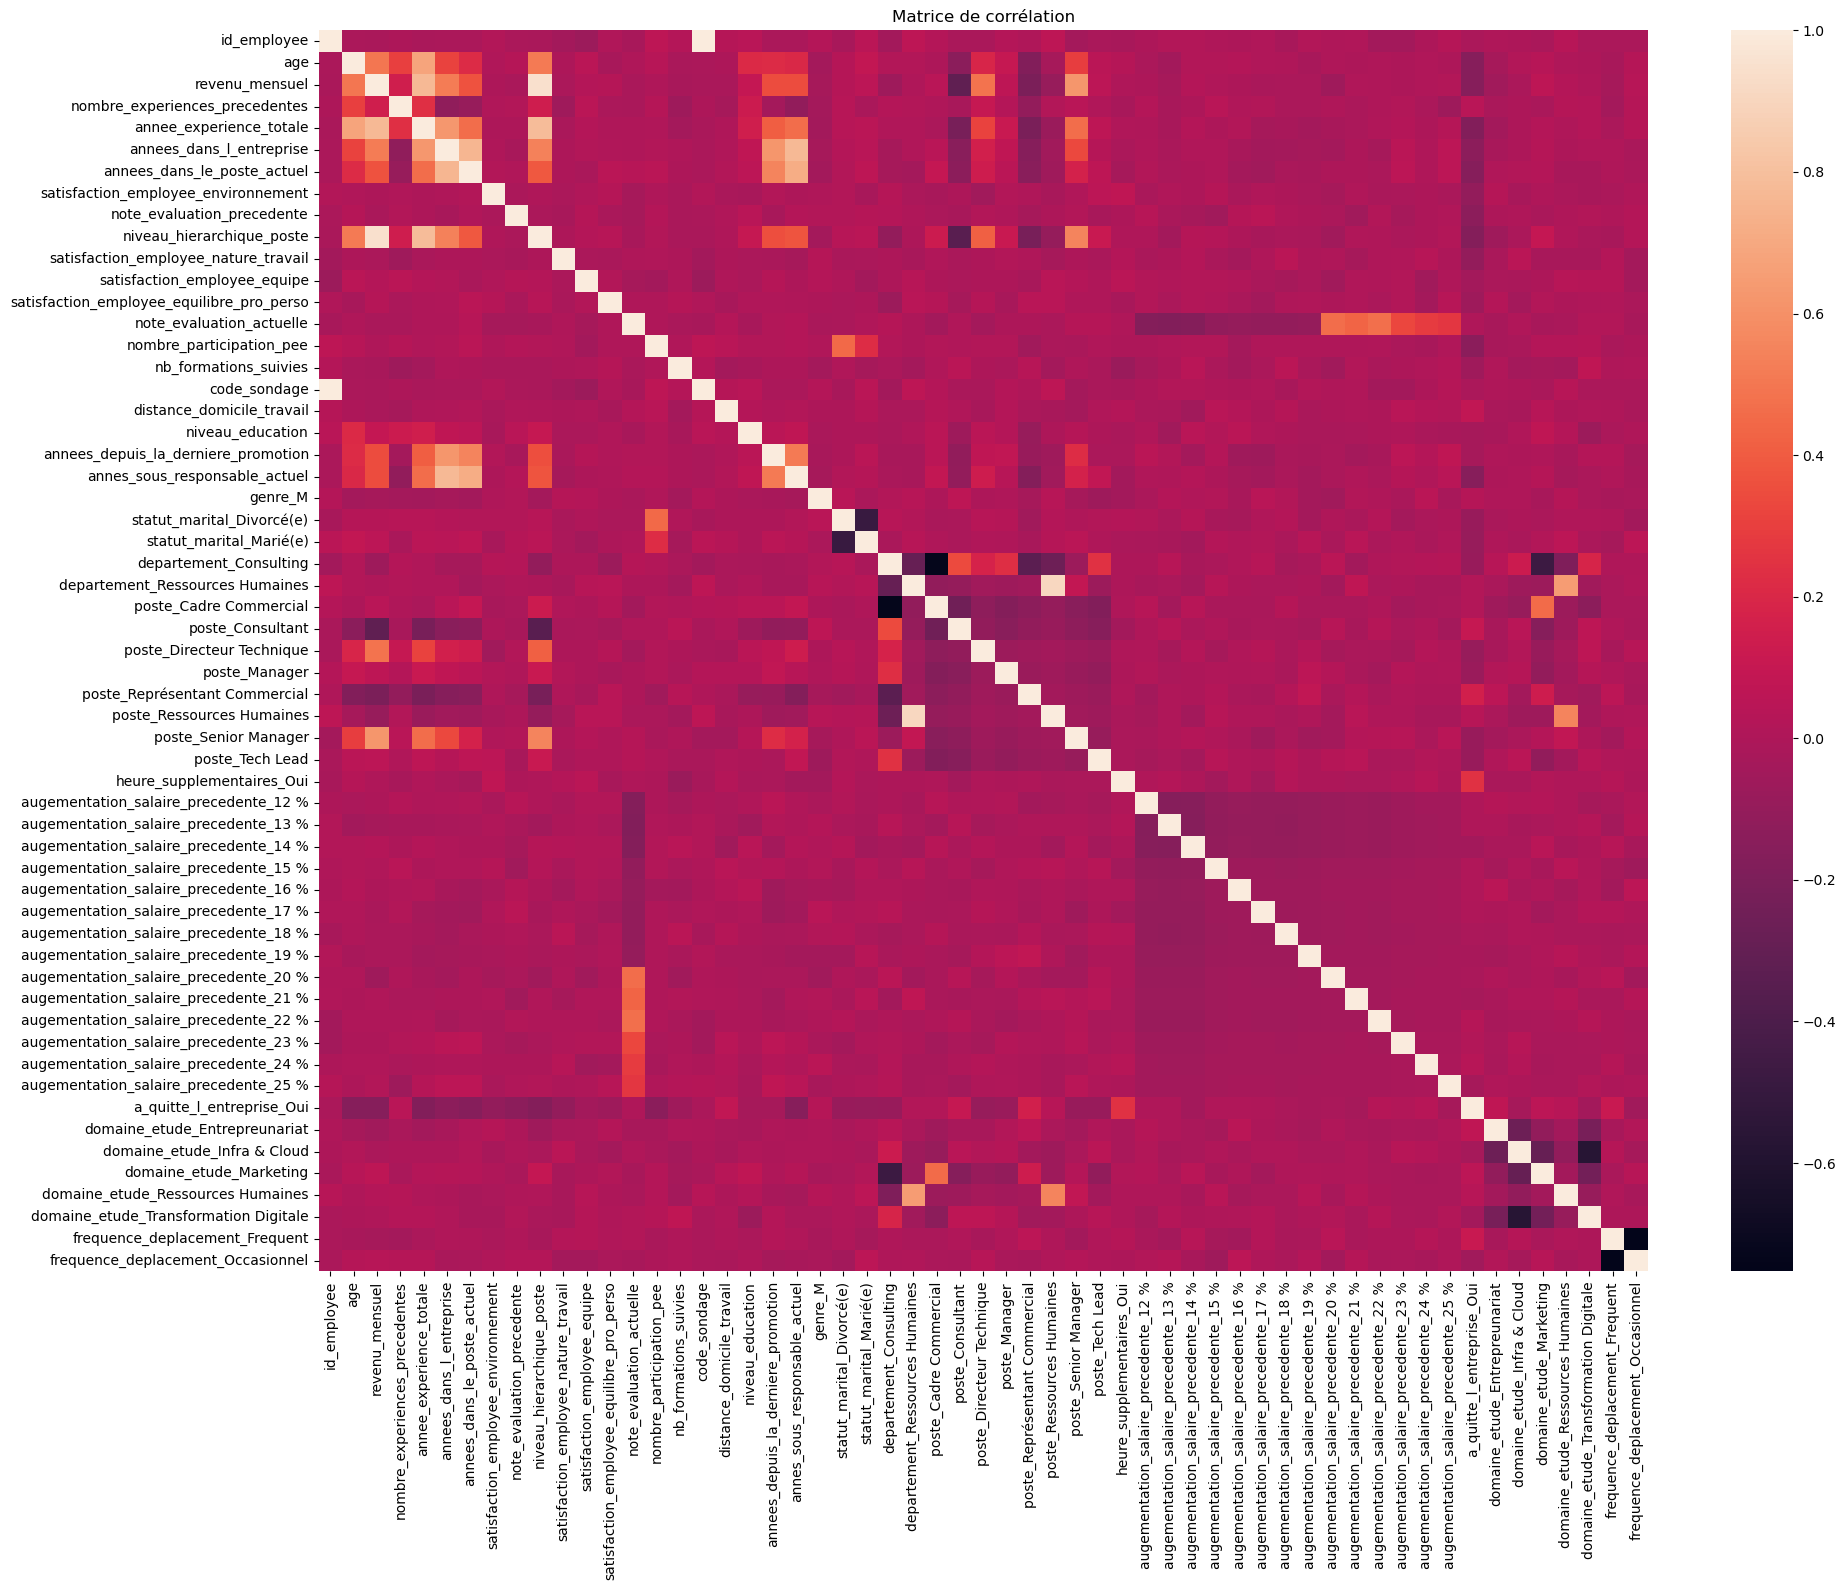

In [101]:
# on affiche graphiquement la corr()
plt.figure(figsize=(20,16))
sns.heatmap(df_corr.corr(numeric_only=True))
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

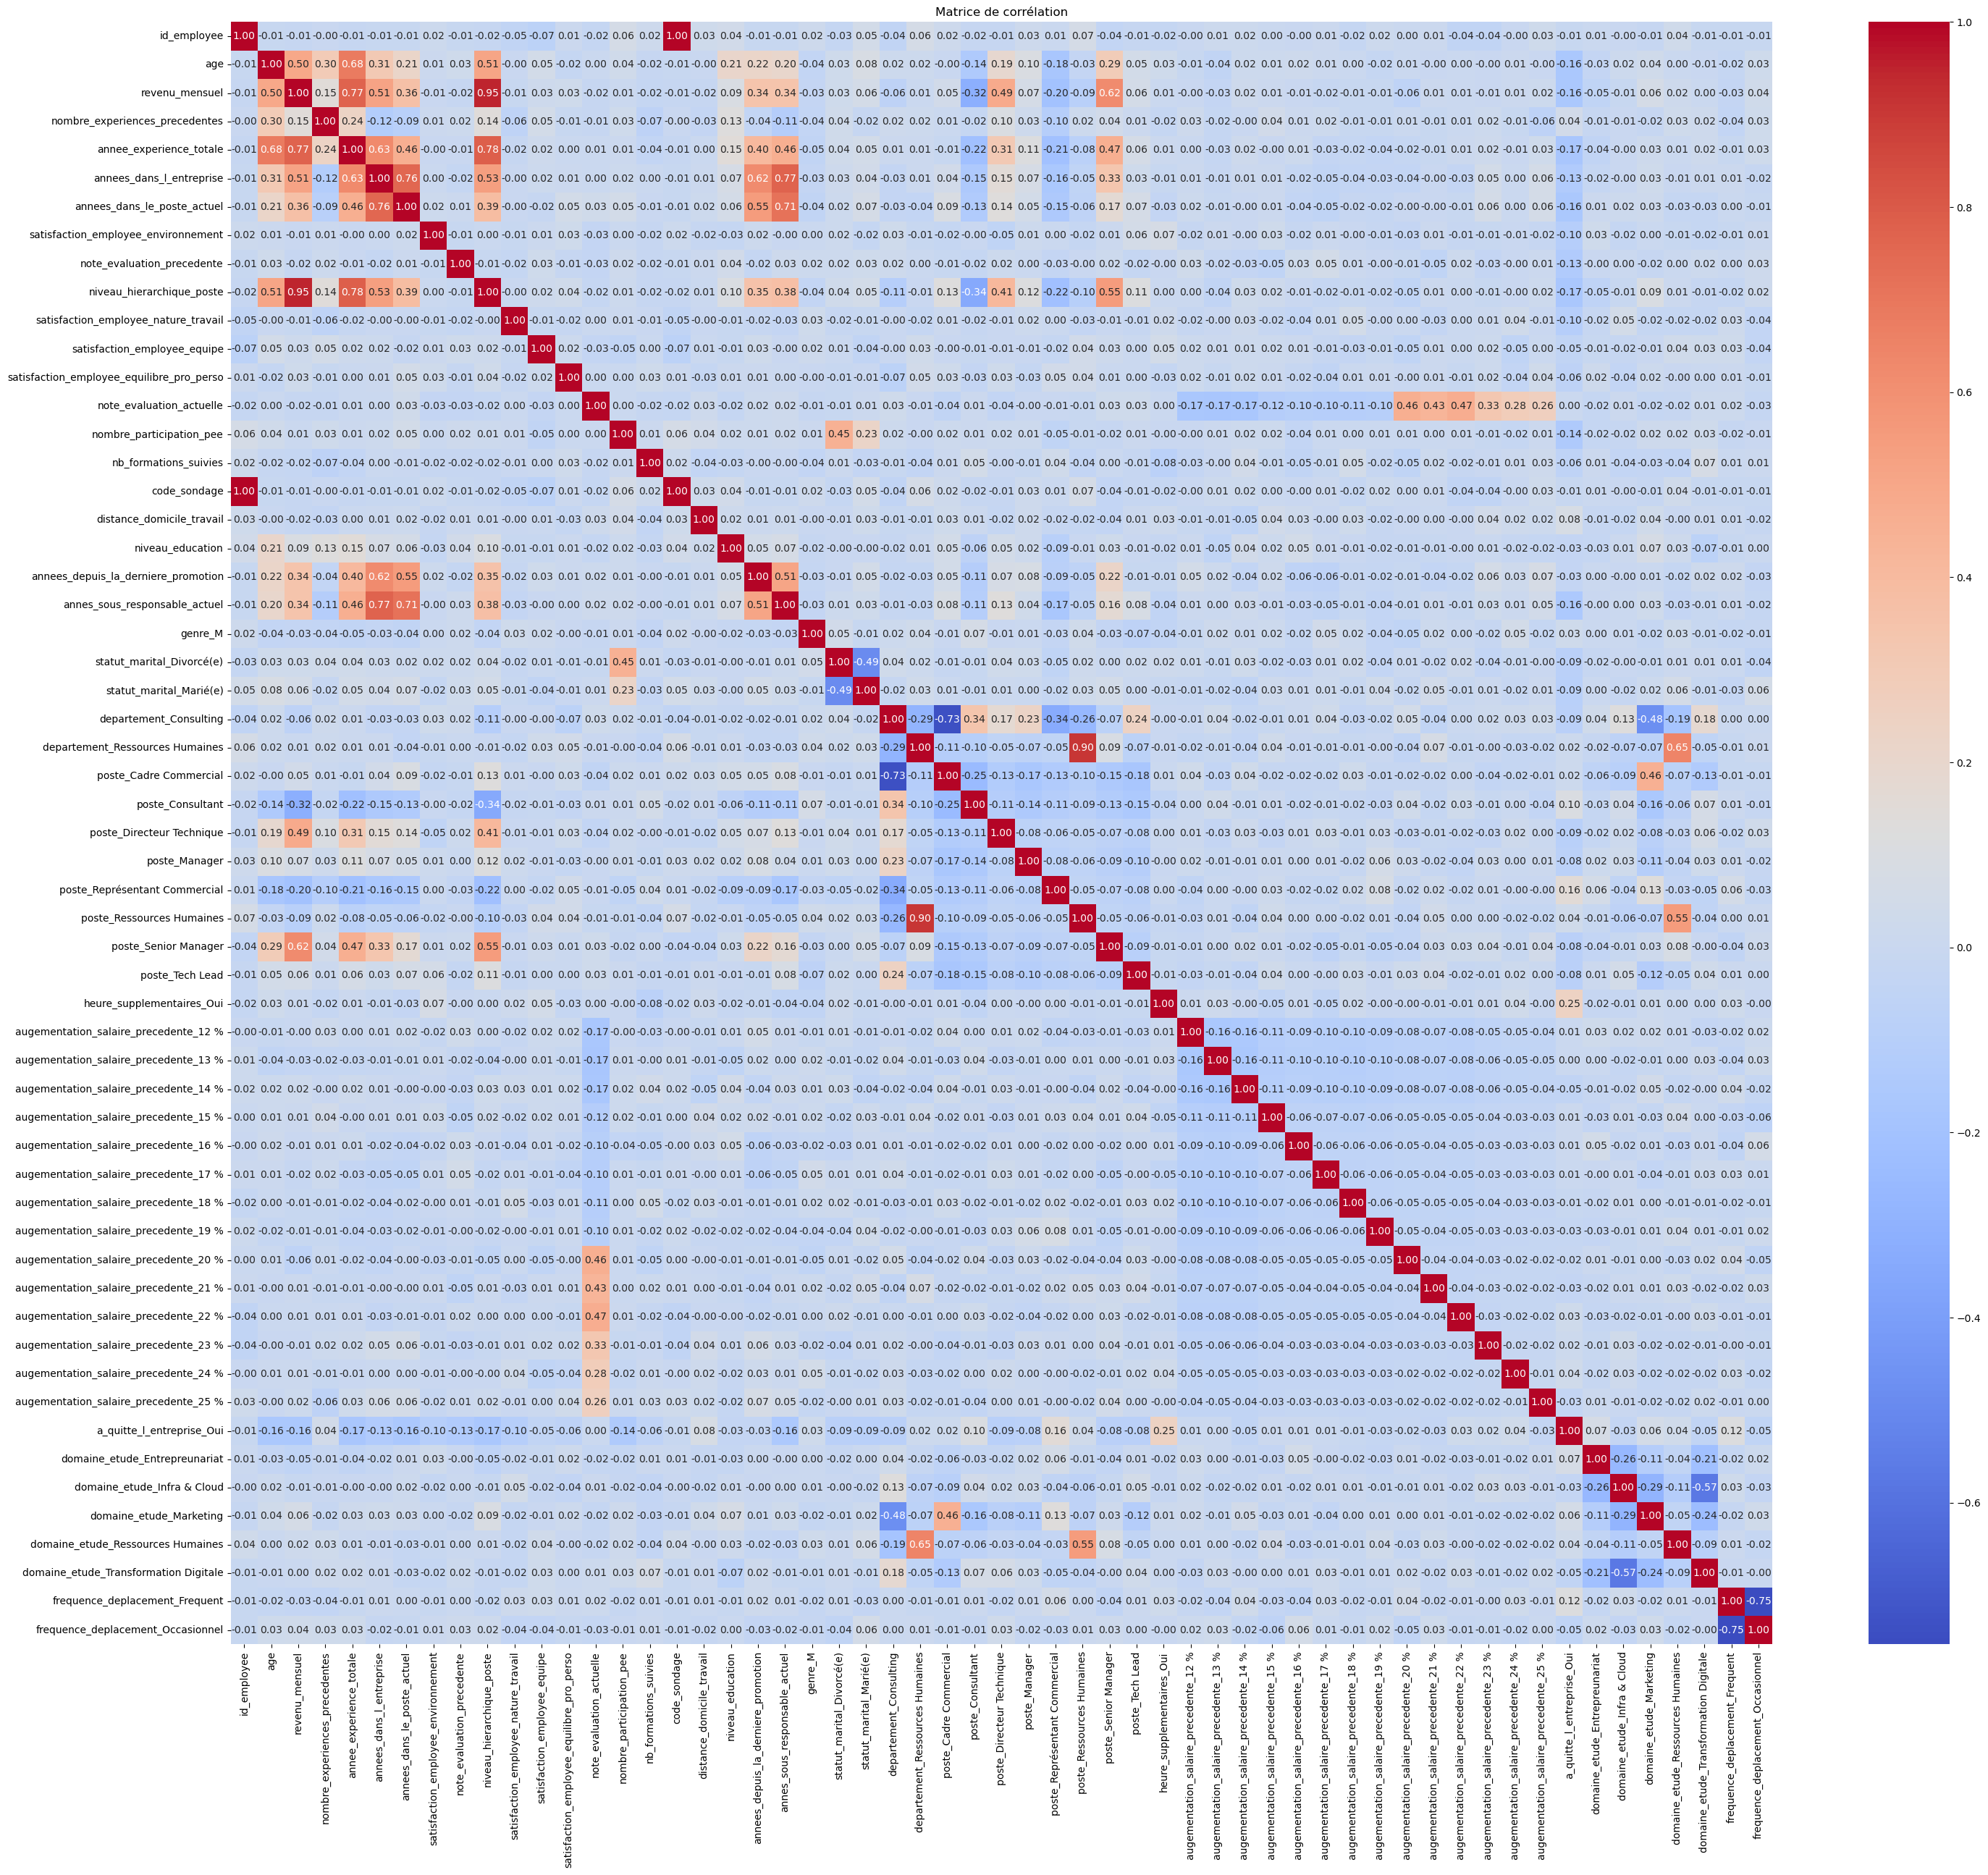

In [102]:
plt.figure(figsize=(30,26))
sns.heatmap(df_corr.corr(numeric_only=True),annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Modèles supervisés

In [103]:
# on décompose le X et y (features et la cible)
X = df_corr.copy()
# on supprime la target dans la features pour eviter le data Leakage
X = X.drop(columns=['a_quitte_l_entreprise_Oui'])
# on recupere le target
y = df_corr['a_quitte_l_entreprise_Oui']

In [104]:
X.shape

(1470, 56)

In [105]:
y.shape

(1470,)

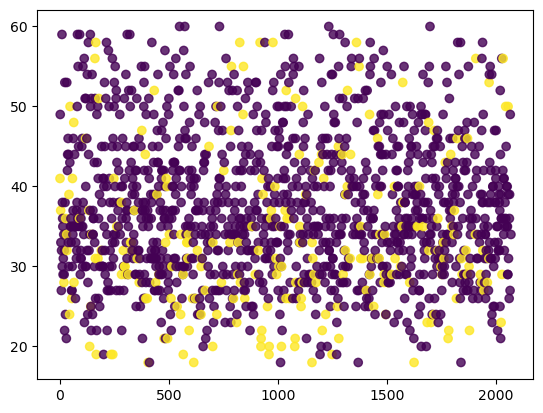

In [106]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, alpha=0.8)

In [107]:
# on separe ici les données dans le code complet X et y (train/test)
# j'utilise import train_test_split dans sklearn.model_selection (il vient du même module de GriDCV Search)
# liens doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5) # 20 pourcent  de train test
print('Train set : ', X_train.shape)
print('Test set : ', X_test.shape)

Train set :  (1176, 56)
Test set :  (294, 56)


Text(0.5, 1.0, 'Test set')

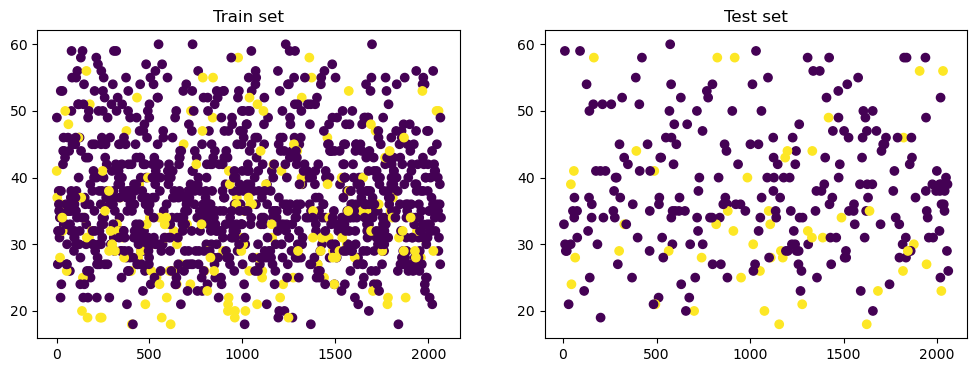

In [108]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train  )
plt.title('Train set')

plt.subplot(122)
plt.scatter(X_test.iloc[:,0], X_test.iloc[:,1], c=y_test  )
plt.title('Test set')

### Scaling

In [109]:
# ici on vas realiser un scaling pour pour ramener toutes les features à la même échelle ex: 0 et 1
# on utilisera la méthode standardScaler() de sklearn.preprocessing import StandardScaler
# doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#scaler.fit(X_train) # on applique uniquement sur le train pour l'apprendre uniquement sur les features X_train
X_train_scaler = scaler.fit_transform(X_train) # on fit_transformes les données sur X_train 
X_test_scaler = scaler.transform(X_test) # on transformes les données sur X_test


In [110]:
# on verifie la moyenne
X_train_scaler.mean()

np.float64(-5.205856262212226e-18)

In [111]:
# on verifie la moyenne
X_train_scaler.std()

np.float64(1.0)

## Etape 3 - Réalisez un premier modèle de classification

In [112]:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# on vas utiliser le modele RandomForest avec les params par défaut
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_val_score

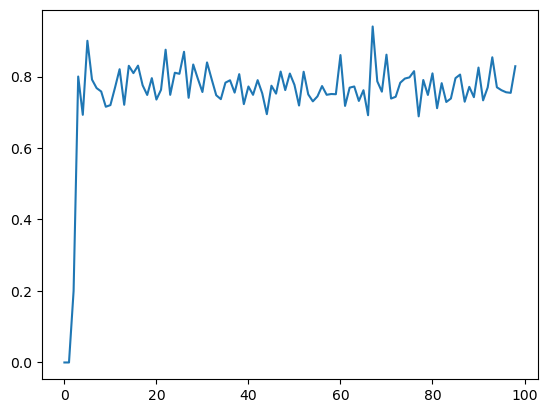

In [113]:
# boucle pour tester le meilleurs param
param = []
for index in range(1, 100):
    score = cross_val_score(RandomForestClassifier(max_depth=index), X_train, y_train, cv=5, scoring='precision').mean()
    param.append(score)

plt.plot(param)

In [114]:
model = RandomForestClassifier()
index = np.arange(0, 100)
train_score, val_score = validation_curve(model, X_train, y_train, param_name='max_depth', param_range=index, cv=5)
print('val_score : ', val_score.shape)
print('val_score : ', train_score.shape)
print('val_score : ', val_score.mean(axis=1))

val_score :  (100, 5)
val_score :  (100, 5)
val_score :  [       nan 0.84013704 0.84013704 0.84183916 0.84523981 0.847793
 0.8503462  0.84949513 0.85289939 0.85119726 0.85205193 0.85715471
 0.85375045 0.85630364 0.85459791 0.85459791 0.84949153 0.8571511
 0.85460512 0.85799856 0.85374684 0.85460151 0.85460512 0.85544537
 0.85460151 0.8529066  0.85120087 0.85375766 0.85289578 0.85289939
 0.85461233 0.85375045 0.85629643 0.8571511  0.85204472 0.85119726
 0.85545618 0.85375045 0.8571511  0.85460151 0.85629282 0.85460512
 0.85204832 0.85290299 0.85545258 0.85544897 0.85460512 0.85630364
 0.8529066  0.85374684 0.85374684 0.85289578 0.85629643 0.85460151
 0.85884962 0.85545979 0.85460151 0.85630725 0.8503498  0.85204832
 0.85799495 0.85715831 0.85374324 0.85630364 0.85630725 0.85885323
 0.85884602 0.85290299 0.85629643 0.85375406 0.85715471 0.85460151
 0.85120087 0.85715471 0.8545943  0.85884962 0.85119726 0.85545258
 0.85375406 0.85460151 0.85545618 0.85204472 0.85374684 0.85459791
 0.85460

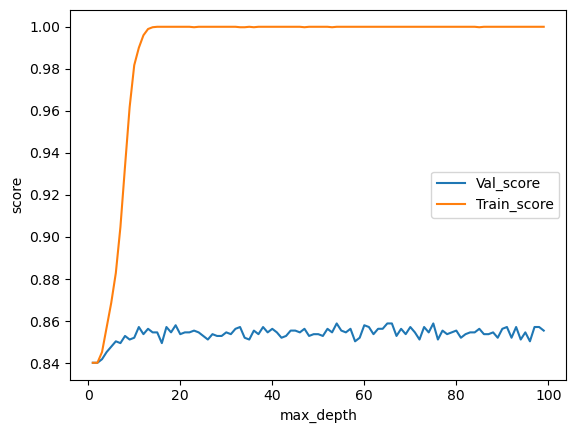

In [115]:
plt.plot(index, val_score.mean(axis=1), label='Val_score')
plt.plot(index, train_score.mean(axis=1), label='Train_score')

plt.ylabel('score')
plt.xlabel('max_depth')

plt.legend()

In [116]:
# avant de commencer on récupere les bon hyper parametres avec gridSearchCV
from sklearn.model_selection import GridSearchCV
import numpy as np
'''
param_grid = {
    'max_depth': np.arange(1, 50),
    'n_estimators': np.arange(1, 50),
}'''
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'n_estimators': [50, 100, 200]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring={
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='f1', # ici refit vas garder le meilleur selon F1
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'max_depth': 10, 'n_estimators': 50}
0.2504048949445457


In [117]:
#profondeur optimale ≈ 10
#nombre d’arbres ≈ 50
#score CV ≈ 85.97%

In [118]:
model = grid.best_estimator_
model.score(X_test, y_test)

0.8503401360544217

In [119]:
y_pred = model.predict(X_test_scaler)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy: 0.40476190476190477
Train score: 0.9719387755102041
Test score: 0.8503401360544217
[[ 78 167]
 [  8  41]]
              precision    recall  f1-score   support

           0       0.91      0.32      0.47       245
           1       0.20      0.84      0.32        49

    accuracy                           0.40       294
   macro avg       0.55      0.58      0.40       294
weighted avg       0.79      0.40      0.45       294



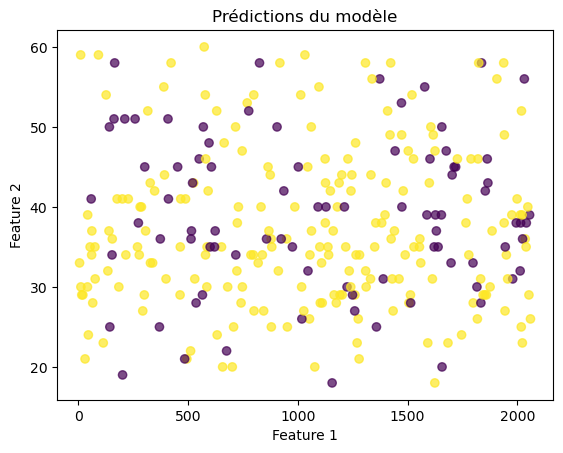

In [120]:

X_np = X_test if hasattr(X_test, "shape") else X_test.to_numpy()

plt.scatter(X_np.iloc[:,0], X_np.iloc[:,1], c=y_pred, alpha=0.7)
plt.title("Prédictions du modèle")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

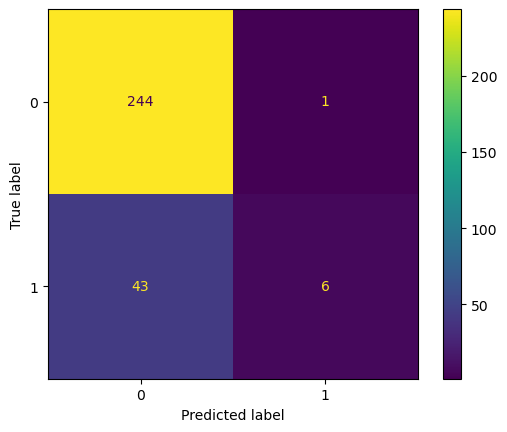

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

## ETAPE 4 - Ameliorez l'approche de la classification

In [122]:
### Amelioration le data avec des nouveau featuring
# ============================================================
# ETAPE 4 - Nouveaux Featurings
# ============================================================

# --- 1. Score de satisfaction global ---
# on additionne les 4 scores de satisfaction et on divise par 4 pour obtenir une moyenne
# un score global bas est un signal fort de démission
df_central['satisfaction_globale'] = (
    df_central['satisfaction_employee_environnement'] +
    df_central['satisfaction_employee_nature_travail'] +
    df_central['satisfaction_employee_equipe'] +
    df_central['satisfaction_employee_equilibre_pro_perso']
) / 4

# --- 2. Stagnation de carrière ---
# on additionne les années sans promotion + années dans le même poste
# plus la valeur est haute, plus l'employé est bloqué dans sa progression
df_central['stagnation'] = (
    df_central['annees_depuis_la_derniere_promotion'] +
    df_central['annees_dans_le_poste_actuel']
)

# --- 3. Revenu par niveau hiérarchique ---
# on divise le revenu mensuel par le niveau hiérarchique
# un ratio bas indique un employé sous-payé par rapport à son poste => risque de départ
# on ajoute +1 pour éviter la division par zéro si niveau_hierarchique_poste = 0
df_central['revenu_par_niveau'] = (
    df_central['revenu_mensuel'] / (df_central['niveau_hierarchique_poste'] + 1)
)

# --- 4. Charge de travail globale ---
# on combine les heures supplémentaires (binaire 0/1) multipliées par le nb d'heures
# + la distance domicile/travail qui contribue à la fatigue globale
df_central['charge_totale'] = (
    df_central['heure_supplementaires_Oui'] * df_central['nombre_heures_travailless'] +
    df_central['distance_domicile_travail']
)
# on vas visualiser de nouveau le dataset
#df_central.info()

In [123]:
# On vas de nouveau corrélé le dataset pour eviter la redondance et identifier le dataleakage
df_data_corr = df_central.copy()
df_data_corr.corr()

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,...,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel,satisfaction_globale,stagnation,revenu_par_niveau,charge_totale
id_employee,1.000000,-0.010145,-0.014829,-0.001251,NaN,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,...,-0.000609,-0.014487,0.035345,-0.008689,-0.007980,-0.007976,-0.049422,-0.009884,-0.000021,-0.016142
age,-0.010145,1.000000,0.497855,0.299635,NaN,0.680381,0.311309,0.212901,0.010146,0.029820,...,0.016824,0.038162,0.001696,-0.006354,-0.024743,0.028791,0.023920,0.243802,0.441186,0.026862
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,NaN,0.772893,0.514285,0.363818,-0.006259,-0.015271,...,-0.007054,0.062576,0.021456,0.001025,-0.031658,0.038779,0.017258,0.403246,0.922200,0.002196
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,NaN,0.237639,-0.118421,-0.090754,0.012594,0.015012,...,-0.006131,-0.018611,0.031007,0.024826,-0.039718,0.032401,0.001702,-0.074256,0.161189,-0.026553
nombre_heures_travailless,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frequence_deplacement_Occasionnel,-0.007976,0.028791,0.038779,0.032401,NaN,0.030320,-0.016274,-0.009147,0.008496,0.026714,...,-0.030355,0.034668,-0.024073,-0.003930,-0.753092,1.000000,-0.040402,-0.023617,0.044367,-0.004912
satisfaction_globale,-0.049422,0.023920,0.017258,0.001702,NaN,0.000749,0.013285,0.017800,0.550303,-0.002954,...,-0.009449,-0.009623,0.005153,-0.006982,0.026752,-0.040402,1.000000,0.021313,0.000135,0.062121
stagnation,-0.009884,0.243802,0.403246,-0.074256,NaN,0.493322,0.786942,0.894376,0.019488,-0.007692,...,0.009703,0.018434,-0.027973,-0.003764,0.013426,-0.023617,0.021313,1.000000,0.370191,-0.020070
revenu_par_niveau,-0.000021,0.441186,0.922200,0.161189,NaN,0.673434,0.446051,0.348561,-0.021922,-0.020118,...,-0.011587,0.067767,0.005332,0.001815,-0.032505,0.044367,0.000135,0.370191,1.000000,0.009395


In [124]:
# ci_dessus on visualise des NAN dans nombre d'heure travaillé on drop cette colonnes
df_data = df_data_corr.drop(columns=['nombre_heures_travailless', 'nombre_employee_sous_responsabilite'])
df_data.corr()

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,...,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel,satisfaction_globale,stagnation,revenu_par_niveau,charge_totale
id_employee,1.000000,-0.010145,-0.014829,-0.001251,-0.014365,-0.011240,-0.008416,0.017621,-0.006888,-0.018519,...,-0.000609,-0.014487,0.035345,-0.008689,-0.007980,-0.007976,-0.049422,-0.009884,-0.000021,-0.016142
age,-0.010145,1.000000,0.497855,0.299635,0.680381,0.311309,0.212901,0.010146,0.029820,0.509604,...,0.016824,0.038162,0.001696,-0.006354,-0.024743,0.028791,0.023920,0.243802,0.441186,0.026862
revenu_mensuel,-0.014829,0.497855,1.000000,0.149515,0.772893,0.514285,0.363818,-0.006259,-0.015271,0.950300,...,-0.007054,0.062576,0.021456,0.001025,-0.031658,0.038779,0.017258,0.403246,0.922200,0.002196
nombre_experiences_precedentes,-0.001251,0.299635,0.149515,1.000000,0.237639,-0.118421,-0.090754,0.012594,0.015012,0.142501,...,-0.006131,-0.018611,0.031007,0.024826,-0.039718,0.032401,0.001702,-0.074256,0.161189,-0.026553
annee_experience_totale,-0.014365,0.680381,0.772893,0.237639,1.000000,0.628133,0.460365,-0.002693,-0.005533,0.782208,...,-0.003630,0.025779,0.005505,0.024890,-0.012177,0.030320,0.000749,0.493322,0.673434,0.013386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frequence_deplacement_Occasionnel,-0.007976,0.028791,0.038779,0.032401,0.030320,-0.016274,-0.009147,0.008496,0.026714,0.023433,...,-0.030355,0.034668,-0.024073,-0.003930,-0.753092,1.000000,-0.040402,-0.023617,0.044367,-0.004912
satisfaction_globale,-0.049422,0.023920,0.017258,0.001702,0.000749,0.013285,0.017800,0.550303,-0.002954,0.024365,...,-0.009449,-0.009623,0.005153,-0.006982,0.026752,-0.040402,1.000000,0.021313,0.000135,0.062121
stagnation,-0.009884,0.243802,0.403246,-0.074256,0.493322,0.786942,0.894376,0.019488,-0.007692,0.423421,...,0.009703,0.018434,-0.027973,-0.003764,0.013426,-0.023617,0.021313,1.000000,0.370191,-0.020070
revenu_par_niveau,-0.000021,0.441186,0.922200,0.161189,0.673434,0.446051,0.348561,-0.021922,-0.020118,0.800644,...,-0.011587,0.067767,0.005332,0.001815,-0.032505,0.044367,0.000135,0.370191,1.000000,0.009395


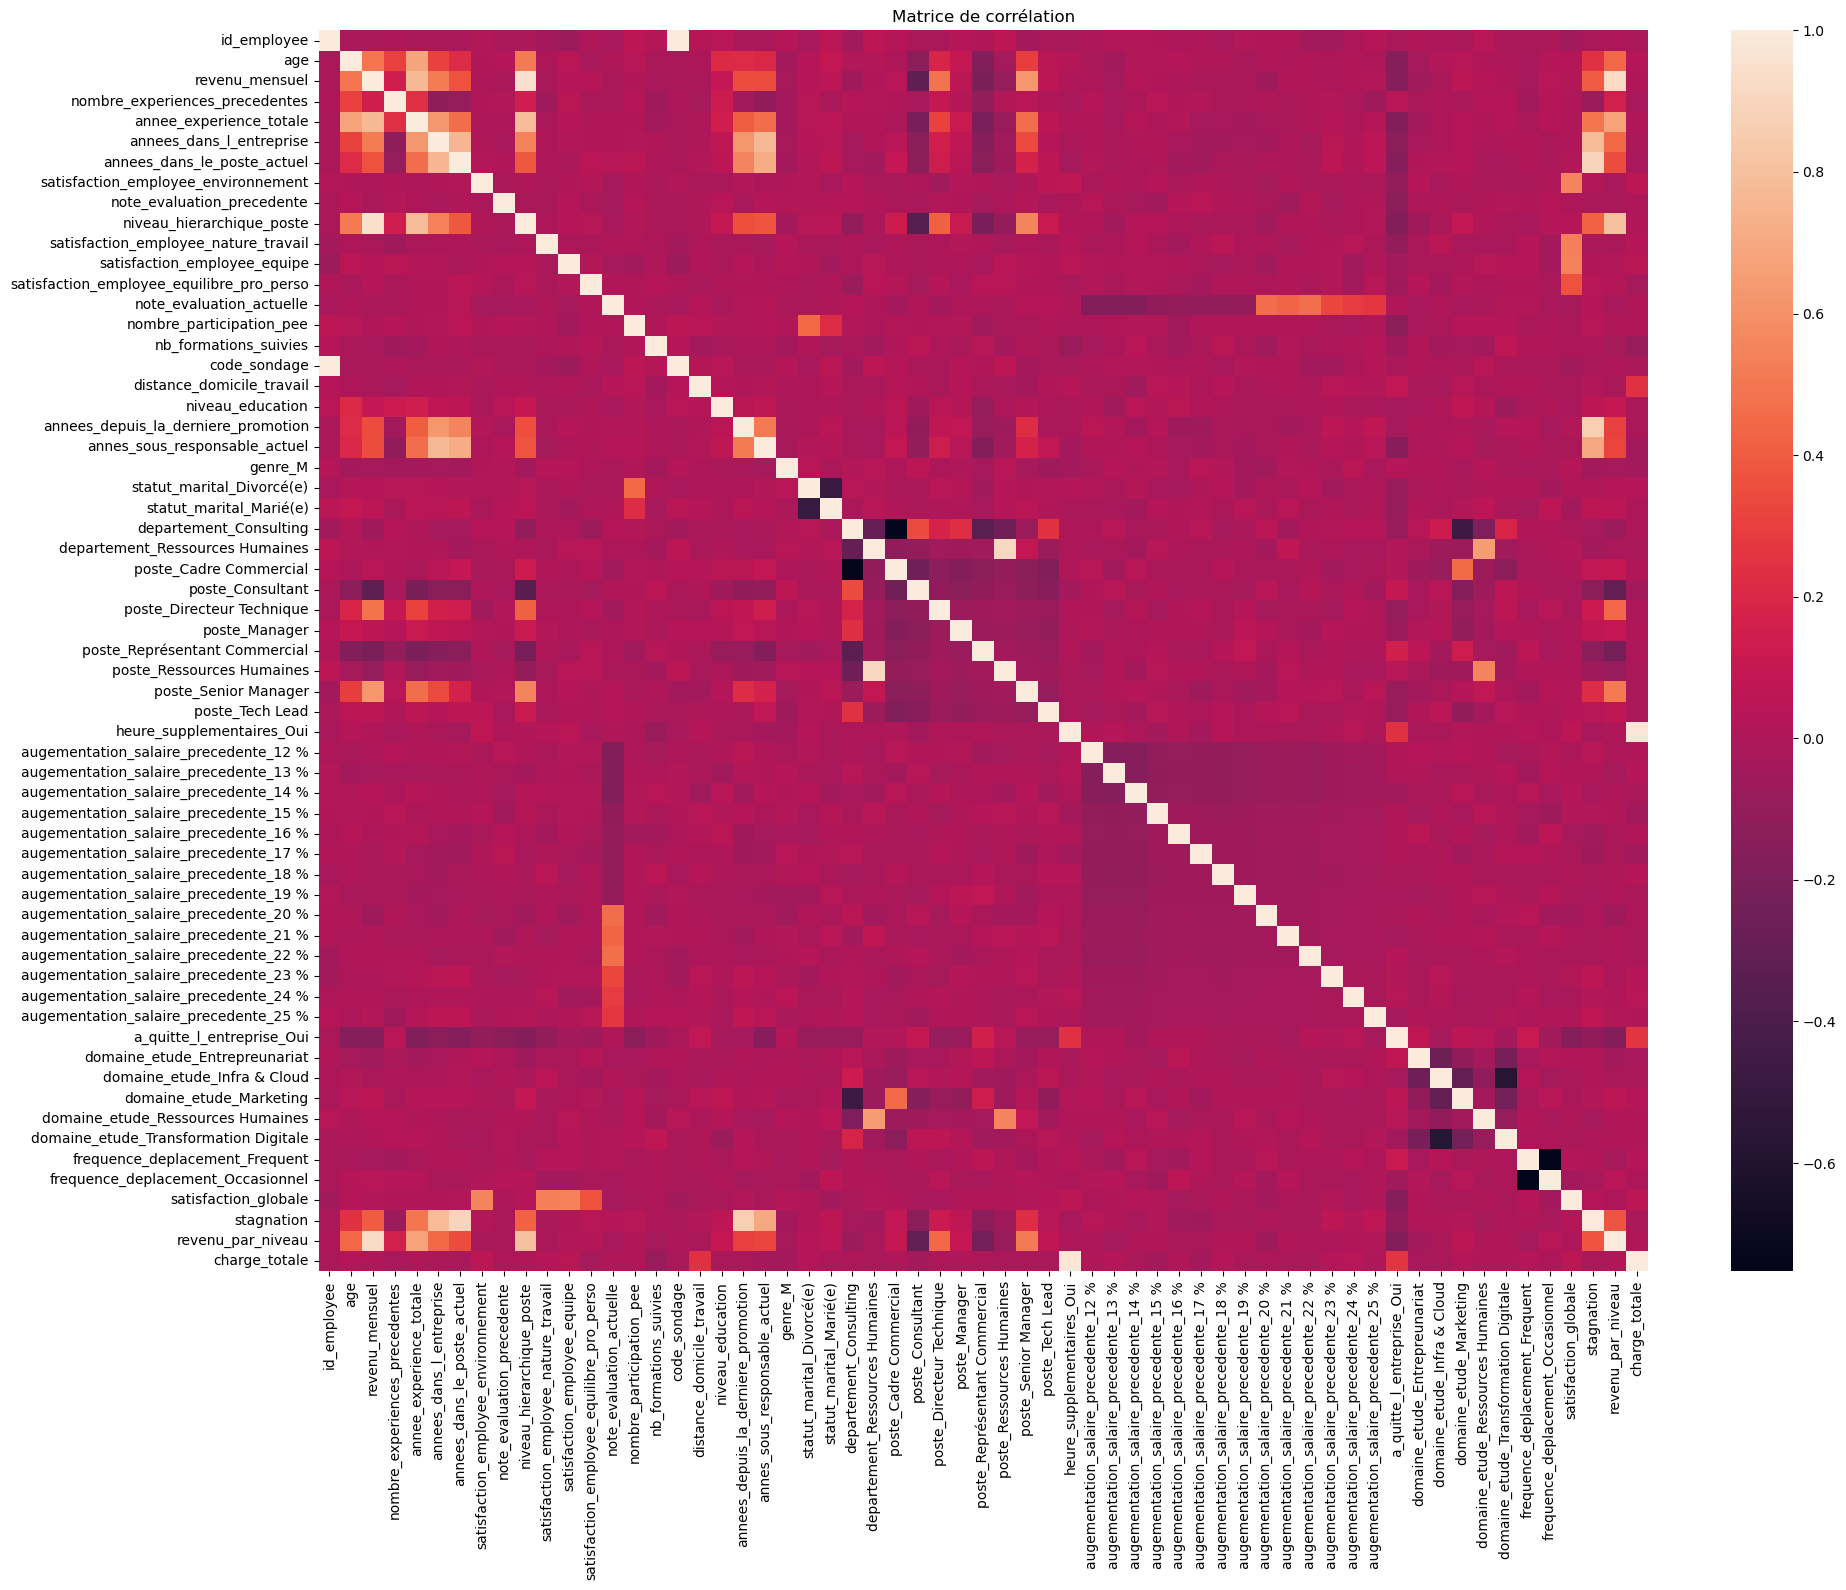

In [125]:
# on affiche graphiquement la corr()
plt.figure(figsize=(20,16))
sns.heatmap(df_data.corr(numeric_only=True))
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

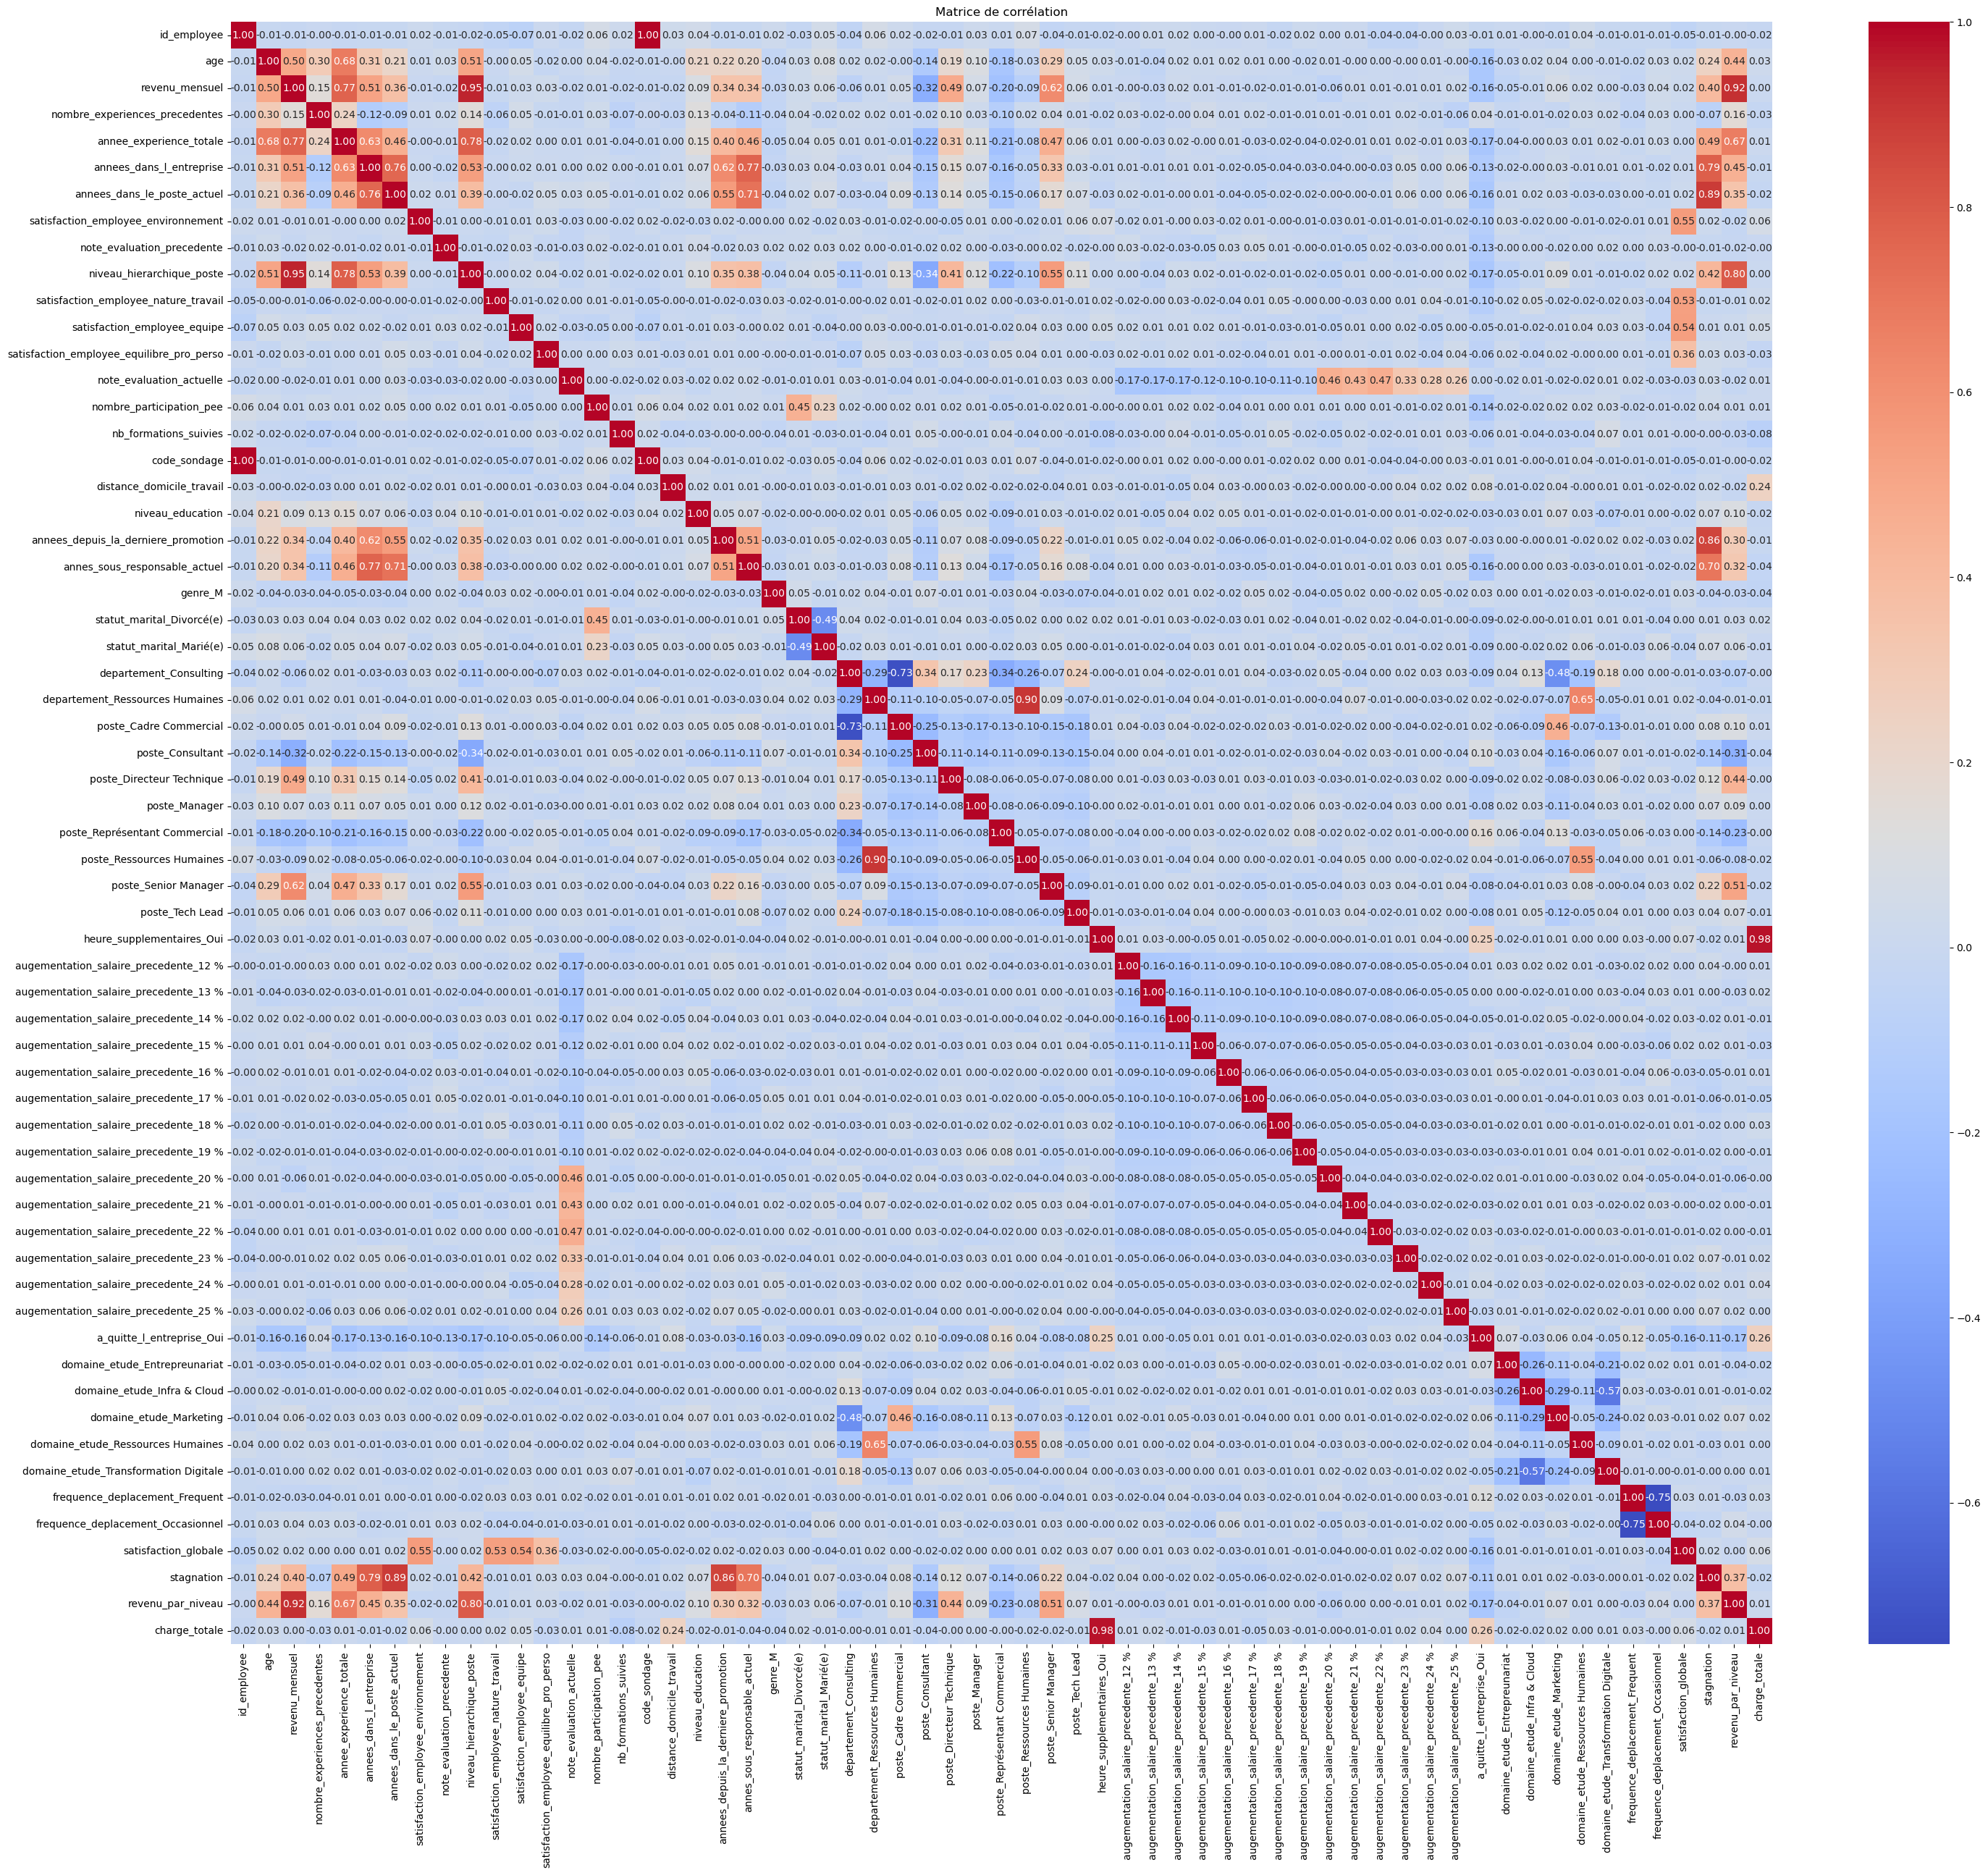

In [126]:
plt.figure(figsize=(30,26))
sns.heatmap(df_data.corr(numeric_only=True),annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [127]:
# on décompose de nouveau les data en X et y avec les nouveau featuring ajouter
# on décompose le X et y (features et la cible)
X = df_data.copy()
# on supprime la target dans la features pour eviter le data Leakage
X = X.drop(columns=['a_quitte_l_entreprise_Oui'])
# on recupere le target
y = df_data['a_quitte_l_entreprise_Oui']

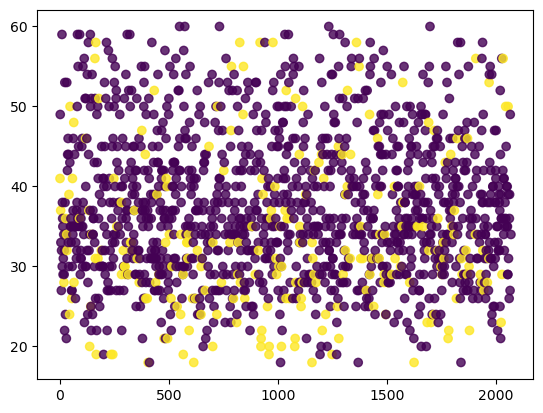

In [128]:
# on visualise les datas X et y 
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y, alpha=0.8)

In [129]:
# on separe ici les données dans le code complet X et y (train/test) des nouveau data
# j'utilise import train_test_split dans sklearn.model_selection (il vient du même module de GriDCV Search)
# liens doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5) # 20 pourcent  de train test
print('Train set : ', X_train.shape)
print('Test set : ', X_test.shape)

Train set :  (1176, 60)
Test set :  (294, 60)


Text(0.5, 1.0, 'Test set')

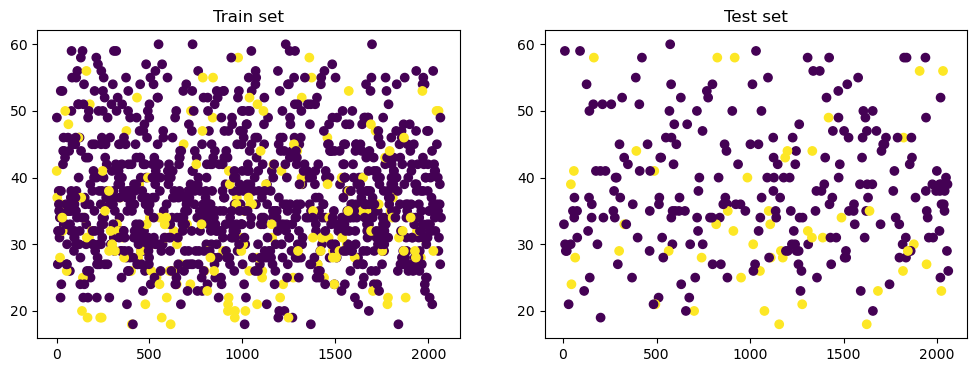

In [130]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train  )
plt.title('Train set')

plt.subplot(122)
plt.scatter(X_test.iloc[:,0], X_test.iloc[:,1], c=y_test  )
plt.title('Test set')

In [131]:
# ici on vas realiser un scaling pour pour ramener toutes les features à la même échelle ex: 0 et 1
# on utilisera la méthode standardScaler() de sklearn.preprocessing import StandardScaler
# doc officiel : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#scaler.fit(X_train) # on applique uniquement sur le train pour l'apprendre uniquement sur les features X_train
X_train_scaler = scaler.fit_transform(X_train) # on fit_transformes les données sur X_train 
X_test_scaler = scaler.transform(X_test) # on transformes les données sur X_test


In [132]:
# on importe KNeighborsClassifier depuis sklearn.neighbors (pas model_selection)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# les hyperparamètres propres à KNN :
# n_neighbors : nombre de voisins à considérer
# metric : distance utilisée (euclidean, manhattan...)
# weights : uniform = tous les voisins comptent pareil / distance = les plus proches comptent plus
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance', 'balanced']
}

grid = GridSearchCV(
    KNeighborsClassifier(),  # pas de random_state sur KNN
    param_grid=param_grid,
    cv=5,
    scoring={
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='f1',
    n_jobs=-1
)

grid.fit(X_train_scaler, y_train)  # KNN est sensible à l'échelle => utilise X_train_scaler

print(grid.best_params_)
print(grid.best_score_)

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
0.30590251518080813


In [133]:
# maintenant qu'on as les meilleurs score on lance best estimator
model = grid.best_estimator_
model.score(X_test_scaler, y_test)

0.8367346938775511

In [134]:
# apres avoir eut le score du model 
# on lance predict pour faire un test accuracy

y_pred = model.predict(X_test_scaler)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Train score:", model.score(X_train_scaler, y_train))
print("Test score:", model.score(X_test_scaler, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy: 0.8367346938775511
Train score: 0.9064625850340136
Test score: 0.8367346938775511
[[238   7]
 [ 41   8]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       245
           1       0.53      0.16      0.25        49

    accuracy                           0.84       294
   macro avg       0.69      0.57      0.58       294
weighted avg       0.80      0.84      0.80       294



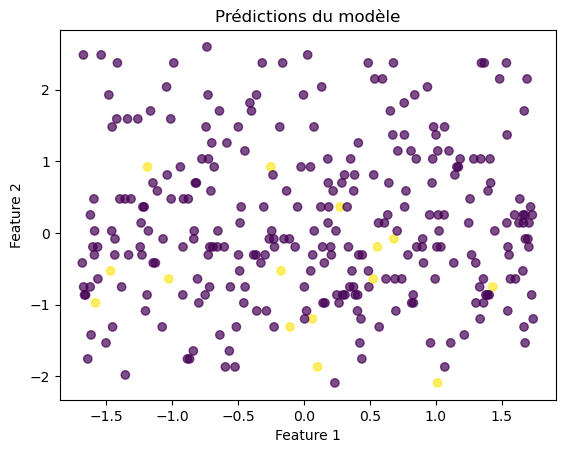

In [135]:
# visualisation de prédictions
X_np = X_test_scaler if hasattr(X_test_scaler, "shape") else X_test_scaler.to_numpy()

plt.scatter(X_np[:,0], X_np[:,1], c=y_pred, alpha=0.7)
plt.title("Prédictions du modèle")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

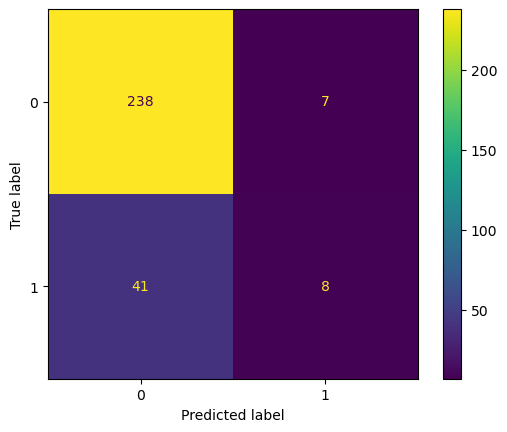

In [136]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test_scaler, y_test)
plt.show()

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Meilleurs params : {'class_weight': 'balanced', 'max_depth': 3, 'n_estimators': 100}
Meilleur score F1 CV : 0.4922051596071165
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       245
           1       0.40      0.59      0.48        49

    accuracy                           0.78       294
   macro avg       0.65      0.71      0.67       294
weighted avg       0.82      0.78      0.80       294



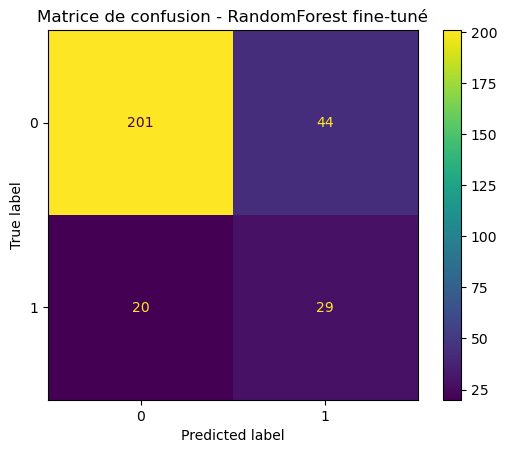

In [137]:
# ============================================================
# ON VAS UTILISER RAMDOMFOREST
# ============================================================
from sklearn.inspection import permutation_importance

# ============================================================
# PARTIE 1 - Fine-tuning RandomForest (modèle à base d'arbre)
# on privilégie RandomForest pour pouvoir utiliser TreeExplainer SHAP
# plus rapide et plus précis que KernelExplainer
# ============================================================
from sklearn.ensemble import RandomForestClassifier

# Je creer a nouveau un param_grid pour gridsearchcv
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'n_estimators': [50, 100, 200],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring={
        'precision': 'precision', 
        'recall': 'recall', 
        'f1': 'f1'},
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaler, y_train)

print("Meilleurs params :", grid_rf.best_params_)
print("Meilleur score F1 CV :", grid_rf.best_score_)

# on récupère le meilleur modèle
model_rf = grid_rf.best_estimator_

# évaluation finale
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_rf = model_rf.predict(X_test_scaler)
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(model_rf, X_test_scaler, y_test)
plt.title("Matrice de confusion - RandomForest fine-tuné")
plt.show()

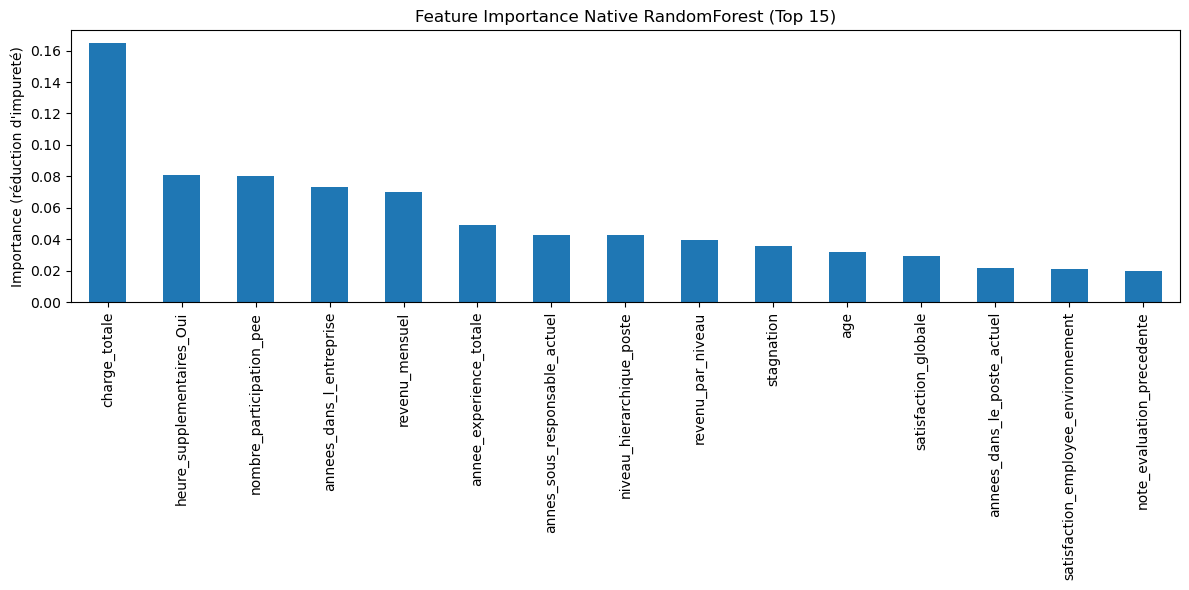

In [138]:
# --- Méthode 1 : Feature Importance Native RandomForest ---
# spécifique aux modèles à base d'arbres
# mesure combien chaque feature réduit l'impureté (Gini) dans les arbres
# avantage : rapide | inconvénient : biaisée vers les features à forte cardinalité

importances_native = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances_native.head(15).plot(kind='bar')
plt.title("Feature Importance Native RandomForest (Top 15)")
plt.ylabel("Importance (réduction d'impureté)")
plt.tight_layout()
plt.show()

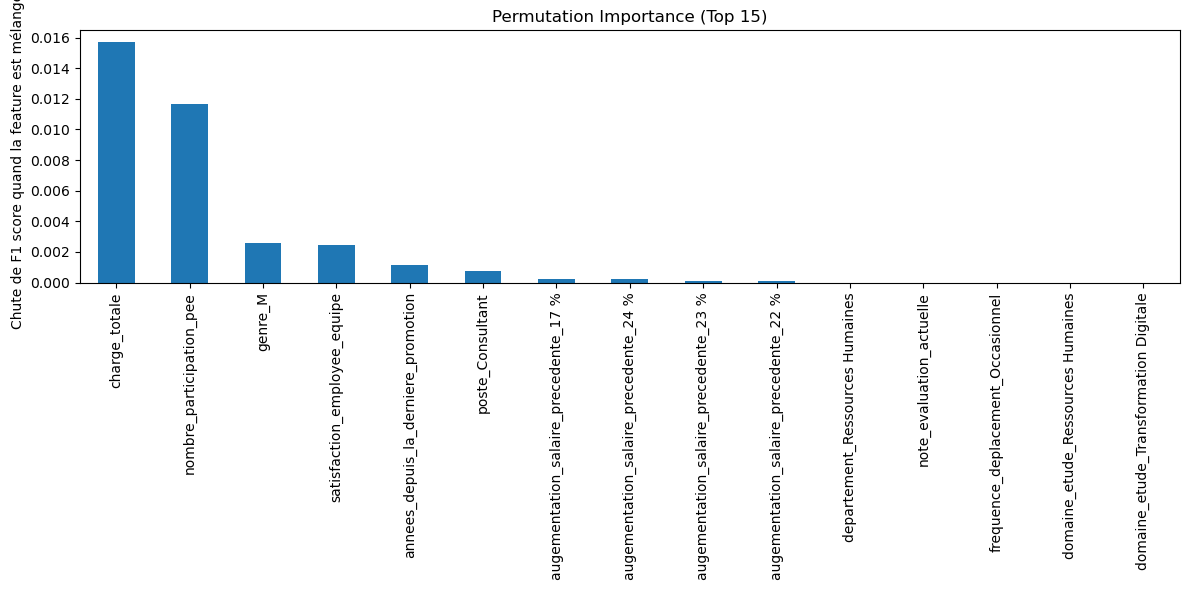

In [139]:
# --- Méthode 2 : Permutation Importance ---
# méthode model-agnostique : mélange aléatoirement une feature et mesure la chute de performance
# plus fiable que la méthode native car ne dépend pas de la structure interne du modèle
# avantage : détecte les vraies features utiles | inconvénient : lent sur gros datasets

perm = permutation_importance(
    model_rf, X_test_scaler, y_test,
    n_repeats=30,       # on répète 30 fois pour stabiliser l'estimation
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

importances_perm = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances_perm.head(15).plot(kind='bar')
plt.title("Permutation Importance (Top 15)")
plt.ylabel("Chute de F1 score quand la feature est mélangée")
plt.tight_layout()
plt.show()

In [140]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(X_test.shape)

NameError: name 'shap_values' is not defined

In [ ]:
# --- Méthode 3 : SHAP Beeswarm Plot ---
# calcule les valeurs de Shapley : contribution de chaque feature pour chaque observation
# on utilise TreeExplainer car notre modèle est un RandomForest (arbre)
# plus précis et rapide que KernelExplainer pour les arbres
import shap
explainer = shap.TreeExplainer(model_rf)

# on calcule les shap values sur le jeu de test
shap_values = explainer.shap_values(X_test)

# shap_values[1] = classe 1 = "a quitté l'entreprise"
# le beeswarm montre pour chaque feature :
#   - axe X : valeur de Shapley (positive = pousse vers démission, négative = pousse vers rester)
#   - couleur : valeur réelle de la feature (rouge = haute, bleu = basse)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="beeswarm",
    max_display=15,
    show=True
)


In [ ]:
# --- Scatter ---
shap_mean = pd.Series(
    np.abs(shap_values[:, :, 1]).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top_feature = shap_mean.index[0]

shap.dependence_plot(
    top_feature,
    shap_values[:, :, 1],   # ← idem
    X_test,
    interaction_index=shap_mean.index[1]
)
plt.show()

In [ ]:
# --- Waterfall local ---
idx_demissionnaires = np.where(y_test.values == 1)[0]
idx_restants        = np.where(y_test.values == 0)[0]

# on crée l'Explanation correctement avec la bonne slice
explanation = shap.Explanation(
    values=shap_values[:, :, 1],              # (294, 60)
    base_values=explainer.expected_value[1],   # valeur de référence classe 1
    data=X_test.values,                        # (294, 60)
    feature_names=X_test.columns.tolist()
)

for i in idx_demissionnaires[:3]:
    shap.plots.waterfall(explanation[i], max_display=10)
    plt.title(f"Employé #{i} → DÉMISSION")
    plt.show()

for i in idx_restants[:3]:
    shap.plots.waterfall(explanation[i], max_display=10)
    plt.title(f"Employé #{i} → RESTE")
    plt.show()